## Linear Regression Task on Life Expectancy

### PART 1: Environment Setup

In [119]:
# Libraries to be used
import os
import zipfile
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
import seaborn as sns
from sklearn.linear_model import LinearRegression

In [120]:
# initialize the path to the zipfile 
path = './data/life-expectancy-and-socio-economic-world-bank.zip'
path_dir = './data'

#extract the zipfile to same directory
with zipfile.ZipFile(path, 'r') as file:
    file.extractall(path_dir)
print('Dataset extracted successfully!')

Dataset extracted successfully!


In [ ]:
# Loading the dataset into a DataFrame
data = pd.read_csv('./data/life expectancy.csv')

# Displaying the first 5 rows of the dataset
data.head()

,Country Name,Country Code,Region,IncomeGroup,Year,Life Expectancy World Bank,Prevelance of Undernourishment,CO2,Health Expenditure %,Education Expenditure %,Unemployment,Corruption,Sanitation,Injuries,Communicable,NonCommunicable
0,Afghanistan,AFG,South Asia,Low income,2001,56.308000,47.8,730.0,NaN,NaN,10.809000,NaN,NaN,2179727.10,9689193.70,5795426.38
1,Angola,AGO,Sub-Saharan Africa,Lower middle income,2001,47.059000,67.5,15960.0,4.483516,NaN,4.004000,NaN,NaN,1392080.71,11190210.53,2663516.34
2,Albania,ALB,Europe & Central Asia,Upper middle income,2001,74.288000,4.9,3230.0,7.139524,3.45870,18.575001,NaN,40.520895,117081.67,140894.78,532324.75
3,Andorra,AND,Europe & Central Asia,High income,2001,NaN,NaN,520.0,5.865939,NaN,NaN,NaN,21.788660,1697.99,695.56,13636.64
4,United Arab Emirates,ARE,Middle East & North Africa,High income,2001,74.544000,2.8,97200.0,2.484370,NaN,2.493000,NaN,NaN,144678.14,65271.91,481740.70
5,Argentina,ARG,Latin America & Caribbean,Upper middle income,2001,73.755000,3.0,125260.0,8.371798,4.83374,17.320000,NaN,48.053996,1397676.07,1507068.98,8070909.52
6,Armenia,ARM,Europe & Central Asia,Upper middle income,2001,71.800000,26.1,3600.0,4.645627,2.46944,10.912000,NaN,46.351896,103371.75,122238.13,767916.19
7,American Samoa,ASM,East Asia & Pacific,Upper middle income,2001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1683.98,2933.98,10752.13
8,Antigua and Barbuda,ATG,Latin America & Caribbean,High income,2001,74.171000,NaN,350.0,5.435876,NaN,NaN,NaN,NaN,2201.12,3279.72,14289.69
9,Australia,AUS,East Asia & Pacific,High income,2001,79.634146,2.5,345640.0,7.696229,NaN,6.740000,NaN,58.788894,612233.81,208282.73,4158052.86


In [ ]:
# Renaming the column names for easier access
data.rename(
    columns={
        'Country Name': 'Country',
        'Country Code': 'Code',
        'IncomeGroup': 'Income_Group',
        'Life Expectancy World Bank': 'Life_Expectancy',
        'Prevelance of Undernourishment': 'Undernourishment',
        'Health Expenditure %': 'Health_Exp',
        'Education Expenditure %': 'Education_Exp'
    },
    inplace=True    
)
data.columns.to_list()

In [122]:
# Displaying the shape of the dataset
print('Dataset has {} rows and {} columns.'.format(data.shape[0], data.shape[1]))

Dataset has 3306 rows and 16 columns.


## PART 2: Exploratory Data Analysis

### Data Overview and Missing Values

In [ ]:
# Getting to Understand more the dataset
data.info()

In [ ]:
#Statistical summary of the dataset
data.describe()

<class 'pandas.DataFrame'>
RangeIndex: 3306 entries, 0 to 3305
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Country           3306 non-null   str    
 1   Code              3306 non-null   str    
 2   Region            3306 non-null   str    
 3   Income_Group      3306 non-null   str    
 4   Year              3306 non-null   int64  
 5   Life_Expectancy   3118 non-null   float64
 6   Undernourishment  2622 non-null   float64
 7   CO2               3154 non-null   float64
 8   Health_Exp        3126 non-null   float64
 9   Education_Exp     2216 non-null   float64
 10  Unemployment      3002 non-null   float64
 11  Corruption        975 non-null    float64
 12  Sanitation        2059 non-null   float64
 13  Injuries          3306 non-null   float64
 14  Communicable      3306 non-null   float64
 15  NonCommunicable   3306 non-null   float64
dtypes: float64(11), int64(1), str(4)
memory usage: 413.4 

In [126]:
# Checking for missing values in the dataset
data.isnull().sum()

Country                0
Code                   0
Region                 0
Income_Group           0
Year                   0
Life_Expectancy      188
Undernourishment     684
CO2                  152
Health_Exp           180
Education_Exp       1090
Unemployment         304
Corruption          2331
Sanitation          1247
Injuries               0
Communicable           0
NonCommunicable        0
dtype: int64

### Data Visualization and Interpretation

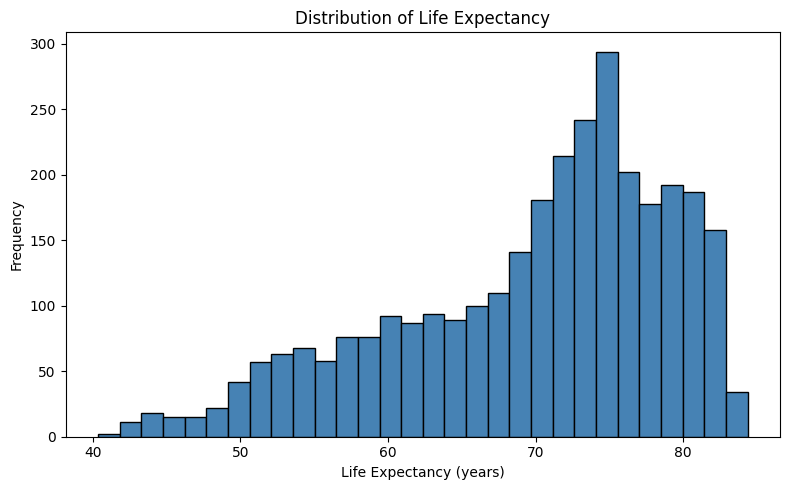

In [127]:
# Histogram of the 'Life expectancy' column which is the target variable

plt.figure(figsize=(8, 5))
plt.hist(data['Life_Expectancy'].dropna(), bins=30, color='steelblue', edgecolor='black')
plt.title('Distribution of Life Expectancy')
plt.xlabel('Life Expectancy (years)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

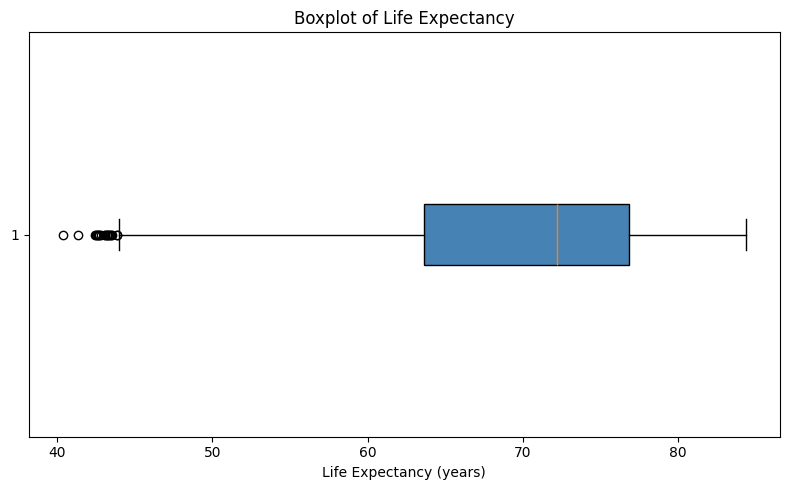

In [128]:
# Boxplot of Life Expectancy to detect outliers
plt.figure(figsize=(8, 5))
plt.boxplot(data['Life_Expectancy'].dropna(), vert=False, patch_artist=True, 
            boxprops=dict(facecolor='steelblue', color='black'))
plt.title('Boxplot of Life Expectancy')
plt.xlabel('Life Expectancy (years)')
plt.tight_layout()
plt.show()

Data Cleaning

In [ ]:
# Dropping Columns with more than 30% missing values
# and nun numeric columns
cleaned_data = data.drop(columns=[
    'Year', # time index
    'Country', #Just a label 
    'Code', # same as country, no numerical value
    'Region', # no numerical value
    'Income_Group', # Categorical label
    'Corruption', # missing 70% of the values
    'Education_Exp', # missing 33% of the values
    'Sanitation' # missing 37.7Z% of the values
    ])
cleaned_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 3306 entries, 0 to 3305
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Life_Expectancy   3118 non-null   float64
 1   Undernourishment  2622 non-null   float64
 2   CO2               3154 non-null   float64
 3   Health_Exp        3126 non-null   float64
 4   Unemployment      3002 non-null   float64
 5   Injuries          3306 non-null   float64
 6   Communicable      3306 non-null   float64
 7   NonCommunicable   3306 non-null   float64
dtypes: float64(8)
memory usage: 206.8 KB


In [130]:
# Filling missing values in numeric columns with the mean of each column
cleaned_data.fillna(cleaned_data.mean(numeric_only=True), inplace=True)
print('The sum of missing values in cleaned_data: ')
print(cleaned_data.isnull().sum())

The sum of missing values in cleaned_data: 
Life_Expectancy     0
Undernourishment    0
CO2                 0
Health_Exp          0
Unemployment        0
Injuries            0
Communicable        0
NonCommunicable     0
dtype: int64


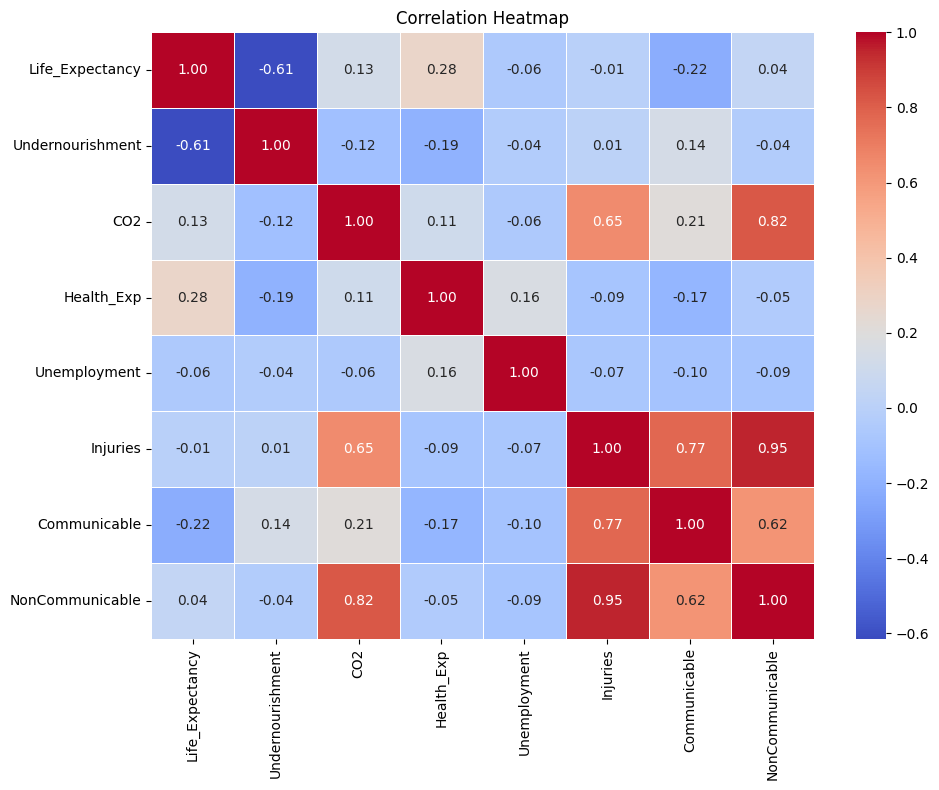

In [131]:
# Hitmap of the correlation on the cleaned dataset
plt.figure(figsize=(10, 8))
sns.heatmap(cleaned_data.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [134]:
# Identifying the features and target variable

# remain with every column except the target variable
X = cleaned_data.drop(columns=['Life_Expectancy']) # features

y = cleaned_data['Life_Expectancy'] # target variable

print('Features: ', X.columns.to_list())
print('Target: ', y.name)
print('Shape of features: ', X.shape)
print('Shape of target: ', y.shape)

Features:  ['Undernourishment', 'CO2', 'Health_Exp', 'Unemployment', 'Injuries', 'Communicable', 'NonCommunicable']
Target:  Life_Expectancy
Shape of features:  (3306, 7)
Shape of target:  (3306,)
